In [1]:
import os
import json
import time
from pathlib import Path
import onnx
import random

import cv2
import numpy as np
import onnxruntime as ort
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torchvision.transforms.functional as TF

from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
from pycocotools.cocoeval import COCOeval

from onnxruntime.quantization import (
    CalibrationDataReader,
    quantize_static,
    QuantType,
    QuantFormat
)

from rfdetr import RFDETRSegPreview

c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_convert = RFDETRSegPreview(pretrain_weights=r"C:\Users\vishn\Downloads\WBC\outputs\output\checkpoint_best_regular.pth")

model_convert.export()

[2026-07-06 17:16:07] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-06 17:16:07] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-06 17:16:08] [WARNING] rf-detr - Checkpoint has 10 classes but model is configured for 90. Using checkpoint class count (10). Pass num_classes=10 to suppress this warning.


[2026-07-06 17:16:08] [INFO] rf-detr - Exporting model to ONNX format


`use_return_dict` is deprecated! Use `return_dict` instead!
c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\rfdetr\models\backbone\dinov2.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert x.shape[2] % block_size == 0 and x.shape[3] % block_size == 0, (
c:\Users\vishn\AppData\Local\Programs\Python\Python312\Lib\site-packages\rfdetr\models\backbone\dinov2_with_windowed_attn.py:313: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if num_channels != self.num_channels:
c:\Users\vishn\AppData\Local\Programs\Python\Python312\

[2026-07-06 17:16:18] [INFO] rf-detr - 
Successfully exported ONNX model: output\inference_model.onnx
[2026-07-06 17:16:18] [INFO] rf-detr - Successfully exported ONNX model to: output\inference_model.onnx
[2026-07-06 17:16:18] [INFO] rf-detr - ONNX export completed successfully


In [3]:
fp32 = r"C:\Users\vishn\Downloads\WBC\output\inference_model.onnx"
int8 = r"C:\Users\vishn\Downloads\WBC\output_int8\inference_model.onnx"

print("FP32:", os.path.getsize(fp32)/1024/1024, "MB")
# print("INT8:", os.path.getsize(int8)/1024/1024, "MB")

FP32: 130.07826709747314 MB


In [4]:
model = onnx.load(fp32)

for inp in model.graph.input:
    print(inp.name)

input


In [5]:
class ImageDataReader(CalibrationDataReader):

    def __init__(self, image_folder, input_name):
        self.input_name = input_name

        self.image_files = [
            os.path.join(image_folder, f)
            for f in os.listdir(image_folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        self.iterator = iter(self.image_files)

    def get_next(self):
        try:
            image_path = next(self.iterator)
        except StopIteration:
            return None

        img = Image.open(image_path).convert("RGB")
        img = img.resize((432, 432))

        img = np.array(img).astype(np.float32)

        img /= 255.0

        img = np.transpose(img, (2, 0, 1))

        img = np.expand_dims(img, 0)

        return {self.input_name: img}

reader = ImageDataReader(
    image_folder=r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images",
    input_name="input"
)

quantize_static(
    model_input=fp32,
    model_output=int8,
    calibration_data_reader=reader,
    quant_format=QuantFormat.QDQ,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8,
)   

In [6]:
# =====================================================
# Paths
# =====================================================

MODEL_PATH = r"C:\Users\vishn\Downloads\WBC\output\inference_model.onnx"

IMAGE_DIR = r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images"

GT_JSON = r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\_annotations.coco.json"

OUTPUT_JSON = "predictions_fp32_1.json"

# =====================================================
# Inference
# =====================================================

INPUT_HEIGHT = 432
INPUT_WIDTH = 432

TOPK = 300

CONF_THRESHOLD = 0.50

# =====================================================
# Normalization
# =====================================================

MEAN = np.array(
    [0.485,0.456,0.406],
    dtype=np.float32
)

STD = np.array(
    [0.229,0.224,0.225],
    dtype=np.float32
)

In [7]:
coco_gt = COCO(GT_JSON)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
categories = sorted(
    coco_gt.dataset["categories"],
    key=lambda x: x["id"]
)

CLASS_TO_CATEGORY = {}
CATEGORY_TO_CLASS = {}
CLASS_NAMES = []

for idx, cat in enumerate(categories):

    CLASS_TO_CATEGORY[idx] = cat["id"]

    CATEGORY_TO_CLASS[cat["id"]] = idx

    CLASS_NAMES.append(cat["name"])

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes :", NUM_CLASSES)

print()

print("Class mapping")

for idx,name in enumerate(CLASS_NAMES):

    print(
        f"{idx:2d} -> Category {CLASS_TO_CATEGORY[idx]:2d} -> {name}"
    )

Number of classes : 10

Class mapping
 0 -> Category  1 -> band cell
 1 -> Category  2 -> basophil
 2 -> Category  3 -> blast cell
 3 -> Category  4 -> eosinophil
 4 -> Category  5 -> lymphocyte
 5 -> Category  6 -> monocyte
 6 -> Category  7 -> neutrophil
 7 -> Category  8 -> promyelocyte
 8 -> Category  9 -> myelocyte
 9 -> Category 10 -> metamyelocyte


In [9]:
image_ids = coco_gt.getImgIds()

print("Validation Images :", len(image_ids))

Validation Images : 117


In [10]:
session = ort.InferenceSession(
    MODEL_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)

INPUT_NAME = session.get_inputs()[0].name

OUTPUT_NAMES = [
    output.name
    for output in session.get_outputs()
]

print("Input")

print(session.get_inputs()[0].name)

print()

print("Outputs")

for out in session.get_outputs():

    print(out.name,out.shape)

Input
input

Outputs
dets [1, 200, 4]
labels [1, 200, 11]
masks [1, 200, 108, 108]


In [11]:
print("="*60)

print("Input Shape")

print(session.get_inputs()[0].shape)

print()

print("Output Shapes")

for output in session.get_outputs():

    print(output.name)

    print(output.shape)

    print(output.type)

    print()

Input Shape
[1, 3, 432, 432]

Output Shapes
dets
[1, 200, 4]
tensor(float)

labels
[1, 200, 11]
tensor(float)

masks
[1, 200, 108, 108]
tensor(float)



In [12]:
sample = coco_gt.loadImgs(image_ids[0])[0]

print(sample)

{'id': 540, 'file_name': 'images/NEUTROPHILS_IMG_3423.jpg', 'width': 256, 'height': 256}


In [13]:
def get_image_path(image_id):

    image_info = coco_gt.loadImgs(image_id)[0]

    file_name = image_info["file_name"]

    # Remove leading "images/" if present
    if file_name.startswith("images/"):
        file_name = file_name[len("images/"):]

    return os.path.join(IMAGE_DIR, file_name)

C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images\NEUTROPHILS_IMG_3423.jpg
(256, 256)


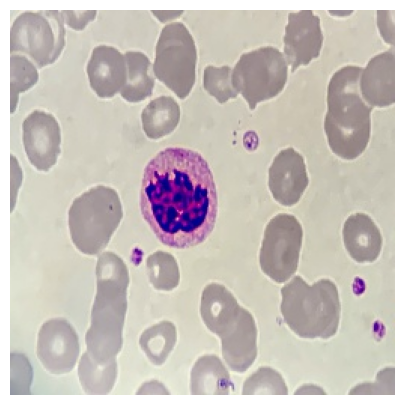

In [14]:
image_path = get_image_path(image_ids[0])

print(image_path)

image = Image.open(image_path)

print(image.size)

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.axis("off")

plt.show()

In [15]:
def preprocess_image(image_path):

    image = Image.open(image_path).convert("RGB")

    original_width, original_height = image.size

    tensor = TF.to_tensor(image)

    tensor = TF.resize(
        tensor,
        [INPUT_HEIGHT, INPUT_WIDTH]
    )

    tensor = TF.normalize(
        tensor,
        mean=MEAN.tolist(),
        std=STD.tolist()
    )

    input_tensor = (
        tensor
        .unsqueeze(0)
        .numpy()
        .astype(np.float32)
    )

    return input_tensor, (original_height, original_width)

In [16]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

In [17]:
def cxcywh_to_xyxy(boxes):

    cx = boxes[:,0]
    cy = boxes[:,1]
    w = boxes[:,2]
    h = boxes[:,3]

    x1 = cx - w/2
    y1 = cy - h/2
    x2 = cx + w/2
    y2 = cy + h/2

    return np.stack(
        [x1,y1,x2,y2],
        axis=1
    )

In [18]:
def postprocess(
    pred_boxes,
    pred_logits,
    pred_masks,
    original_size,
    topk=TOPK
):

    H,W = original_size

    pred_boxes = pred_boxes[0]
    pred_logits = pred_logits[0]
    pred_masks = pred_masks[0]

    scores = sigmoid(pred_logits)

    num_queries,num_classes = scores.shape

    scores = scores.reshape(-1)

    k = min(topk,len(scores))

    topk_idx = np.argpartition(
        -scores,
        k-1
    )[:k]

    topk_scores = scores[topk_idx]

    order = np.argsort(
        -topk_scores
    )

    topk_scores = topk_scores[order]

    topk_idx = topk_idx[order]

    query_idx = topk_idx // num_classes

    labels = topk_idx % num_classes

    boxes = pred_boxes[query_idx]

    boxes = cxcywh_to_xyxy(boxes)

    boxes[:,[0,2]] *= W
    boxes[:,[1,3]] *= H

    boxes[:,[0,2]] = np.clip(
        boxes[:,[0,2]],
        0,
        W
    )

    boxes[:,[1,3]] = np.clip(
        boxes[:,[1,3]],
        0,
        H
    )

    selected_masks = pred_masks[query_idx]

    resized_masks = []

    for mask in selected_masks:

        mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)

        mask_tensor = F.interpolate(
            mask_tensor,
            size=(H, W),
            mode="bilinear",
            align_corners=False,
        )

        resized_masks.append(
            (mask_tensor.squeeze().numpy() > 0)
        )

    resized_masks = np.asarray(resized_masks)

    return {

        "scores":topk_scores,

        "labels":labels,

        "boxes":boxes,

        "masks":resized_masks

    }

In [19]:
def run_onnx(image_path):

    input_tensor, original_size = preprocess_image(
        image_path
    )

    outputs = session.run(

        None,

        {
            INPUT_NAME:input_tensor
        }

    )

    result = postprocess(

        outputs[0],

        outputs[1],

        outputs[2],

        original_size

    )

    return result

In [20]:
image_path = get_image_path(
    image_ids[0]
)

result = run_onnx(
    image_path
)

print("Total predictions :",len(result["scores"]))

print()

print("Highest score :",result["scores"][0])

print()

print("Class :",CLASS_NAMES[result["labels"][0]])

Total predictions : 300

Highest score : 0.9651387

Class : neutrophil


Visible detections : 1


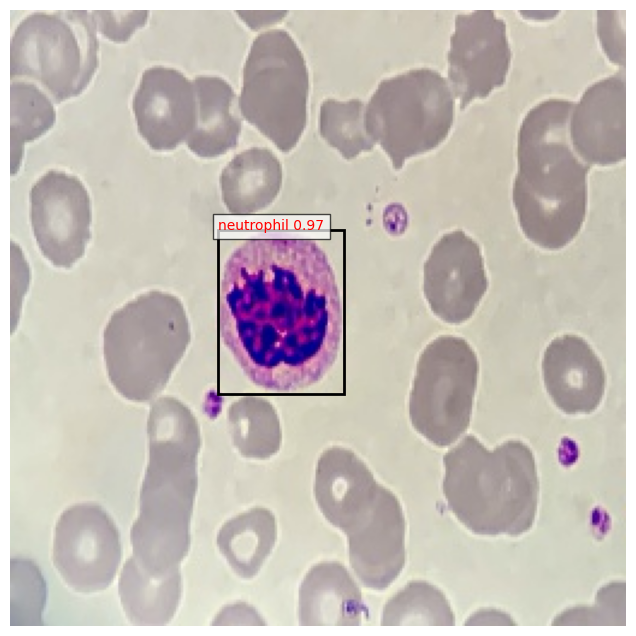

In [21]:
image = np.array(
    Image.open(image_path).convert("RGB")
)

plt.figure(figsize=(8,8))

plt.imshow(image)

ax = plt.gca()

count = 0

for box,score,label in zip(

    result["boxes"],

    result["scores"],

    result["labels"]

):

    if score < CONF_THRESHOLD:
        continue

    count += 1

    x1,y1,x2,y2 = box

    ax.add_patch(

        patches.Rectangle(

            (x1,y1),

            x2-x1,

            y2-y1,

            linewidth=2,

            fill=False,

        )

    )

    ax.text(

        x1,

        y1,

        f"{CLASS_NAMES[label]} {score:.2f}",

        color="red",

        fontsize=10,

        bbox=dict(facecolor="white",alpha=0.7)

    )

print("Visible detections :",count)

plt.axis("off")

plt.show()

In [22]:
def results_to_coco(
    result,
    image_id,
):

    predictions = []

    for score, label, box, mask in zip(
        result["scores"],
        result["labels"],
        result["boxes"],
        result["masks"],
    ):

        if score < CONF_THRESHOLD:
            continue

        x1, y1, x2, y2 = box

        bbox = [
            float(x1),
            float(y1),
            float(x2 - x1),
            float(y2 - y1),
        ]

        mask = np.asfortranarray(
            mask.astype(np.uint8)
        )

        rle = maskUtils.encode(mask)

        rle["counts"] = rle["counts"].decode("utf-8")

        predictions.append(
            {
                "image_id": int(image_id),
                "category_id": int(
                    CLASS_TO_CATEGORY[int(label)]
                ),
                "bbox": bbox,
                "segmentation": rle,
                "score": float(score),
            }
        )

    return predictions

In [23]:
all_predictions = []

total_images = len(image_ids)

print(f"Processing {total_images} images...\n")

for image_id in tqdm(image_ids):

    image_path = get_image_path(image_id)

    result = run_onnx(image_path)

    preds = results_to_coco(
        result,
        image_id,
    )

    all_predictions.extend(preds)

print("\nDone.")

print("Total predictions:", len(all_predictions))

Processing 117 images...



100%|██████████| 117/117 [01:27<00:00,  1.34it/s]


Done.
Total predictions: 154


In [24]:
with open(
    OUTPUT_JSON,
    "w",
) as f:

    json.dump(
        all_predictions,
        f,
    )

print("Saved:", OUTPUT_JSON)

Saved: predictions_fp32_1.json


In [25]:
print("First prediction:\n")

print(json.dumps(
    all_predictions[0],
    indent=2,
)[:1200])

First prediction:

{
  "image_id": 540,
  "category_id": 7,
  "bbox": [
    86.1441650390625,
    91.13099670410156,
    52.34474182128906,
    67.824462890625
  ],
  "segmentation": {
    "size": [
      256,
      256
    ],
    "counts": "ice0:^7<G8J4N3L3N3M2N3M2N3M2N3N1N2N2O0O2O001O0O1000001O0001O0000000O101O001N10001O0O2O1N2N2N3M2N4L3L4M4K5J8G\\\\m0"
  },
  "score": 0.9651386737823486
}


In [26]:
MODEL_PATH_ONNX = r"C:\Users\vishn\Downloads\WBC\output\inference_model.onnx"

session = ort.InferenceSession(
    MODEL_PATH_ONNX,
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name

In [27]:
def run_onnx(image_path):

    input_tensor, original_size = preprocess_image(image_path)

    outputs = session.run(
        None,
        {input_name: input_tensor}
    )

    result = postprocess(
        outputs[0],
        outputs[1],
        outputs[2],
        original_size
    )

    return result

In [28]:
def benchmark_onnx(image_folder):

    image_files = [
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]

    # Warm-up
    for img in image_files[:5]:
        run_onnx(img)

    start = time.perf_counter()

    for img in tqdm(image_files):
        run_onnx(img)

    end = time.perf_counter()

    total_time = end - start
    total_images = len(image_files)

    latency = total_time / total_images
    fps = total_images / total_time
    throughput = fps

    print("="*45)
    print(f"Images        : {total_images}")
    print(f"Total Time    : {total_time:.4f} sec")
    print(f"Latency       : {latency*1000:.2f} ms/image")
    print(f"FPS           : {fps:.2f}")
    print(f"Throughput    : {throughput:.2f} images/sec")
    print("="*45)

    return latency, fps, throughput

In [29]:
onnx_latency, onnx_fps, onnx_throughput = benchmark_onnx(
    r"C:\Users\vishn\Downloads\WBC\outputs\dataset\valid\images"
)

100%|██████████| 117/117 [01:26<00:00,  1.35it/s]

Images        : 117
Total Time    : 86.8964 sec
Latency       : 742.70 ms/image
FPS           : 1.35
Throughput    : 1.35 images/sec
